In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 재현성을 위한 seed 설정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [87]:
# 데이터 로드
df = pd.read_csv('../../data/processed/cleaned_disease_dataset_2015landuse.csv')

print(f"Total samples: {len(df):,}")
df.head()


# 컬럼 분류
key_cols = ['year', 'country', 'admin']
#target_col = 'infection_rate'
target_col = 'infection_risk_level'
climate_cols = ['max_temperature', 'min_temperature', 'avg_temperature']
livestock_cols = ['Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine']
landuse_cols = ['rate_landuse']
feature_cols = climate_cols + livestock_cols + landuse_cols

print(f"Feature 컬럼 ({len(feature_cols)}개): {feature_cols}")
print(f"Target 컬럼: {target_col}")

Total samples: 473
Feature 컬럼 (11개): ['max_temperature', 'min_temperature', 'avg_temperature', 'Cattl', 'Chick', 'Ducks', 'Goats', 'Horse', 'Sheep', 'Swine', 'rate_landuse']
Target 컬럼: infection_risk_level


- Buffa feature 삭제

In [88]:
#자연발생 클러스터링
from jenkspy import JenksNaturalBreaks

df.columns

i = 3

breaks = JenksNaturalBreaks(n_classes=i)
breaks.fit(df["infection_rate"])
print(breaks.breaks_)  # 구간 경계

df["infection_risk_level"] = pd.cut(
    df["infection_rate"], bins=breaks.breaks_, labels=range(i), include_lowest=True
)
df["infection_risk_level"].value_counts()


# X, y 분리
X = df[feature_cols].copy()
y = df[target_col].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


# train, test dataset 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("=== Random Split ===")
print(f"Train set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

[0.0, 6.027164685908319, 15.030674846625766, 27.07340324118208]
X shape: (473, 11)
y shape: (473,)
=== Random Split ===
Train set: 378 samples (79.9%)
Test set: 95 samples (20.1%)


In [89]:
#  랜덤포레스트 
rf = RandomForestClassifier(random_state = 0)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('자연발생 클러스터링 기반 랜덤 포레스트 정확도: {:.4f}'.format(accuracy))

자연발생 클러스터링 기반 랜덤 포레스트 정확도: 0.8526


In [90]:
!pip install imbalanced-learn

In [91]:
# SMOTE 기법
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# 1. 가짜 데이터를 생성해서 Mid, High 개수를 Low만큼 뻥튀기합니다.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 뻥튀기된 데이터로 학습 (가중치 옵션 없이도 데이터가 많아서 잘 배움)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled) # resampled 데이터 사용!

# 3. 평가
pred = rf.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.97      0.94        67
           1       0.71      0.50      0.59        20
           2       0.67      0.75      0.71         8

    accuracy                           0.85        95
   macro avg       0.76      0.74      0.74        95
weighted avg       0.84      0.85      0.84        95



count of each level in train data


infection_risk_level
0    273
1     55
2     50
Name: count, dtype: int64

count of each level in test data


infection_risk_level
0    67
1    20
2     8
Name: count, dtype: int64

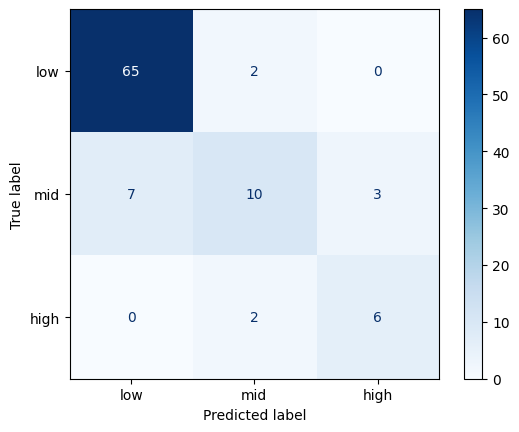

In [92]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# (1) level 별로 train/test data에서 개수 확인
print("count of each level in train data")
display(pd.Series(y_train).value_counts())
print("count of each level in test data")
display(pd.Series(y_test).value_counts())

# (2) rf 모델에서 class_weight="balanced" 인자 설정에 따른 성능 차이 확인하기 -> 차이 없음 -> 데이터 불균형의 영향 적음
cm = confusion_matrix(y_test, pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["low", "mid", "high"])
disp.plot(cmap="Blues")

### analysis 1. learning curve + best parameter
- 과적합 여부 확인
- 최적 파라미터(모델) 찾기

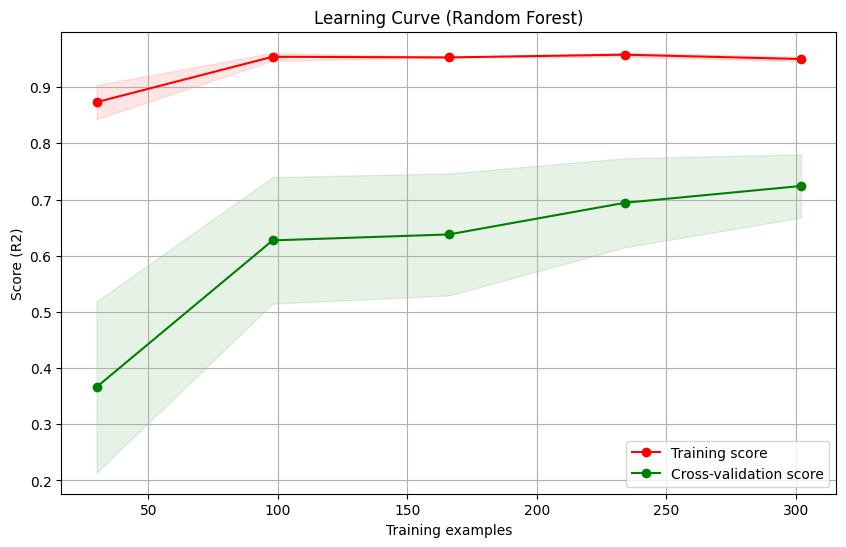

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    estimator: 사용할 모델 (예: RandomForestRegressor())
    X, y: 학습 데이터 (X_train, y_train)
    cv: 교차 검증 폴드 수 (기본 5)
    train_sizes: 학습 데이터 크기 비율 (10% ~ 100%까지 5구간으로 쪼개서 확인)
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score (R2)")

    # learning_curve 함수가 알아서 train/validation을 나누고 점수를 계산해줍니다.
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='r2'
    )

    # 평균과 표준편차 계산 (그래프에 영역 표시용)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    # 영역 칠하기 (표준편차 범위)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    # 실선 그리기 (평균 점수)
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

# === 실행하기 ===
# 1. 모델 설정 (아까 설정하신 파라미터 그대로 쓰세요)
# 가지치기(max_depth)를 안 하면 Training score가 무조건 1에 가깝게 나와서 과적합 확인이 잘 됩니다.
rf_model = RandomForestRegressor(n_estimators=100, random_state=15, max_depth=7) 

# 2. 함수 호출 (X_train, y_train을 넣으세요)
plot_learning_curve(rf_model, "Learning Curve (Random Forest)", X_train, y_train, cv=5)

최적의 파라미터 값 찾기

In [94]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. 튜닝할 파라미터의 범위 지정 (후보군)
param_grid = {
    'n_estimators': [100, 200],          # 나무의 개수
    'max_depth': [5,6, 7, 10, None],       # 나무의 깊이 (None은 무제한)
    'min_samples_leaf': [1, 2, 4],       # 잎사귀 최소 샘플 수
    'min_samples_split': [2, 5, 10],     # 분할을 위한 최소 샘플 수
    'max_features': ['sqrt', 'log2']     # 변수 선택 방식 (auto는 전체 사용)
}

# 2. 모델 준비
rf = RandomForestClassifier(random_state=15)

# 3. 그리드 서치 설정
# cv=5: 데이터를 5개로 쪼개서 교차 검증 (데이터가 적으므로 필수)
# n_jobs=-1: CPU 코어 다 써서 빨리 계산해라
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, scoring='r2', verbose=1)

# 4. 학습 시작 (시간이 조금 걸릴 수 있음)
print("최적의 파라미터를 찾는 중입니다...")
grid_search.fit(X_train, y_train)

# 5. 결과 확인
print("\n=== 튜닝 결과 ===")
print(f"가장 좋은 파라미터: {grid_search.best_params_}")
print(f"가장 좋은 교차검증 점수: {grid_search.best_score_:.4f}")

# 6. 최적의 모델로 Test Set 평가
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print(f"최적 모델의 Test R2 Score: {test_score:.4f}")

최적의 파라미터를 찾는 중입니다...
Fitting 5 folds for each of 180 candidates, totalling 900 fits

=== 튜닝 결과 ===
가장 좋은 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
가장 좋은 교차검증 점수: 0.7283
최적 모델의 Test R2 Score: 0.8526


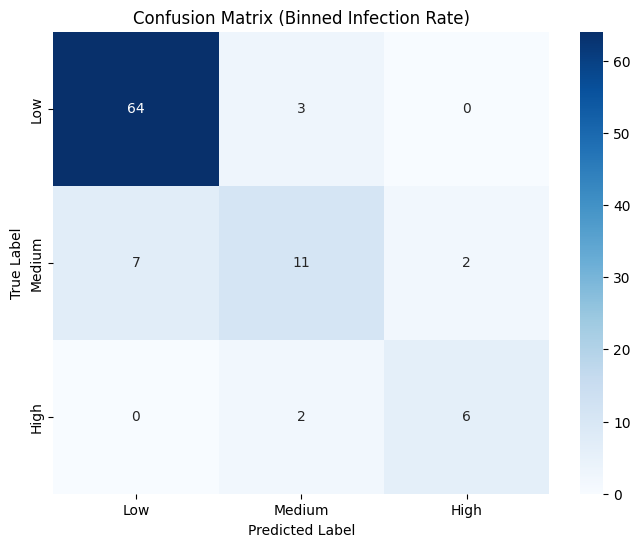

=== 분류 관점에서의 성능 평가 ===
              precision    recall  f1-score   support

         Low       0.90      0.96      0.93        67
      Medium       0.69      0.55      0.61        20
        High       0.75      0.75      0.75         8

    accuracy                           0.85        95
   macro avg       0.78      0.75      0.76        95
weighted avg       0.84      0.85      0.85        95



In [95]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# SMOTE 기법
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# 1. 가짜 데이터를 생성해서 Mid, High 개수를 Low만큼 뻥튀기합니다.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 뻥튀기된 데이터로 학습 (가중치 옵션 없이도 데이터가 많아서 잘 배움)
rf = grid_search.best_estimator_
rf.fit(X_train_resampled, y_train_resampled) # resampled 데이터 사용!

# 
pred = rf.predict(X_test)

# 4. Confusion Matrix 생성
cm = confusion_matrix(y_test, pred)
class_names = ['Low', 'Medium', 'High']

# 5. 시각화 (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Binned Infection Rate)')
plt.show()

# 6. 상세 점수 확인
print("=== 분류 관점에서의 성능 평가 ===")
print(classification_report(y_test, pred, target_names=class_names))

/Users/sseongyunn/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/sseongyunn/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/sseongyunn/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sseongyunn/.pyenv/version

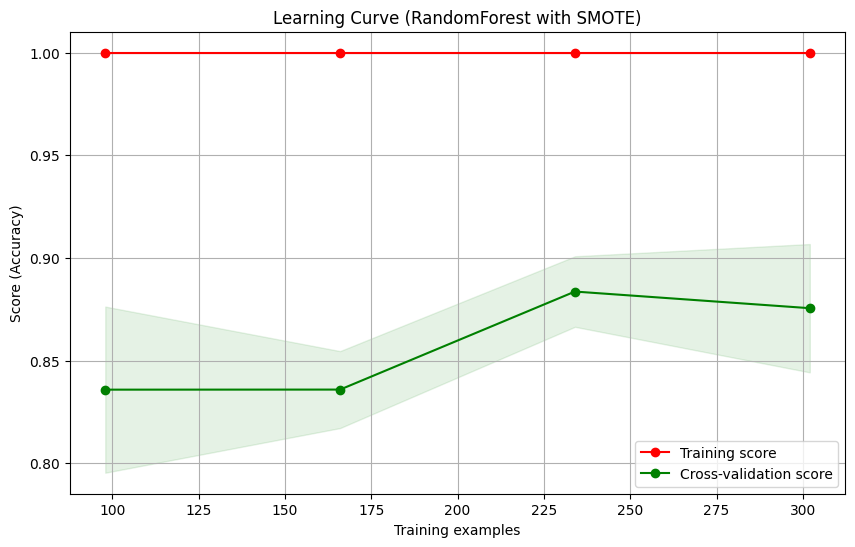

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
# sklearn의 pipeline이 아닌 imblearn의 pipeline을 써야 SMOTE가 중간에 적용됩니다.
from imblearn.pipeline import Pipeline as ImbPipeline 
from imblearn.over_sampling import SMOTE

def plot_learning_curve_with_smote(estimator, title, X, y, ylim=None, cv=5,
                                   n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    SMOTE를 포함한 파이프라인으로 Learning Curve를 그리는 함수
    """
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score (Accuracy)")

    # 1. SMOTE + 모델 파이프라인 구축
    # (CV를 돌릴 때마다 'Train Fold'에만 SMOTE를 적용하고, 'Validation Fold'는 원본을 유지함)
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', estimator)
    ])

    # 2. learning_curve 실행
    # 주의: 여기서 X, y는 뻥튀기 전의 '원본(X_train, y_train)'을 넣어야 합니다.
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='accuracy'
    )

    # 평균과 표준편차 계산
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid()

    # 영역 칠하기 (표준편차 범위)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")

    # 선 그리기
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    plt.show()

# === 실행하기 ===
# grid_search.best_estimator_ 가 RandomForest라고 가정합니다.
# best_rf_model = grid_search.best_estimator_ 

# [중요] X_train_resampled가 아니라 원본 'X_train', 'y_train'을 넣으세요!
# 파이프라인 안에서 알아서 SMOTE를 적용해줍니다.
plot_learning_curve_with_smote(
    rf, 
    "Learning Curve (RandomForest with SMOTE)", 
    X_train, y_train, 
    cv=5
)

수동 수정 후 Test Score: 0.8526


/Users/sseongyunn/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/sseongyunn/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/sseongyunn/.pyenv/versions/3.12.2/lib/python3.12/site-packages/sklearn/base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sseongyunn/.pyenv/version

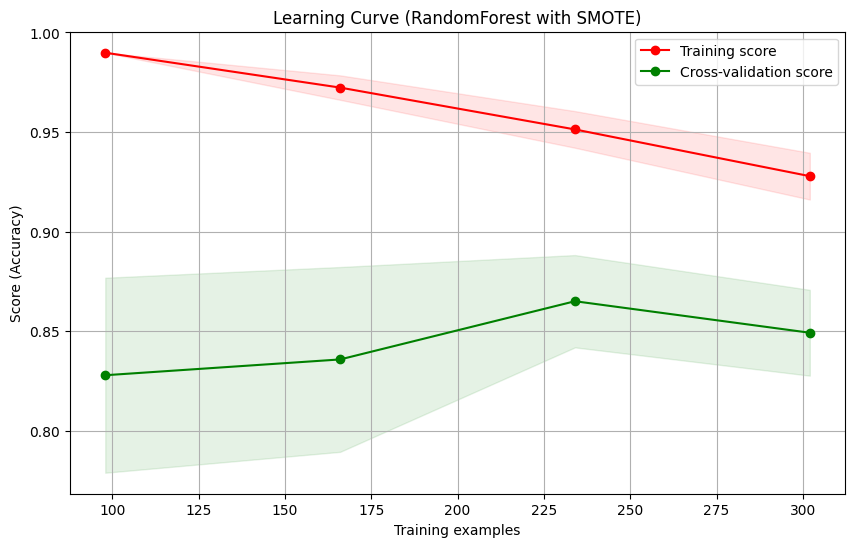

In [74]:
best_model.set_params(max_depth=5)
best_model.fit(X_train, y_train)

# 4. 평가
print(f"수동 수정 후 Test Score: {best_model.score(X_test, y_test):.4f}")

plot_learning_curve_with_smote(
    best_model, 
    "Learning Curve (RandomForest with SMOTE)", 
    X_train, y_train, 
    cv=5
)

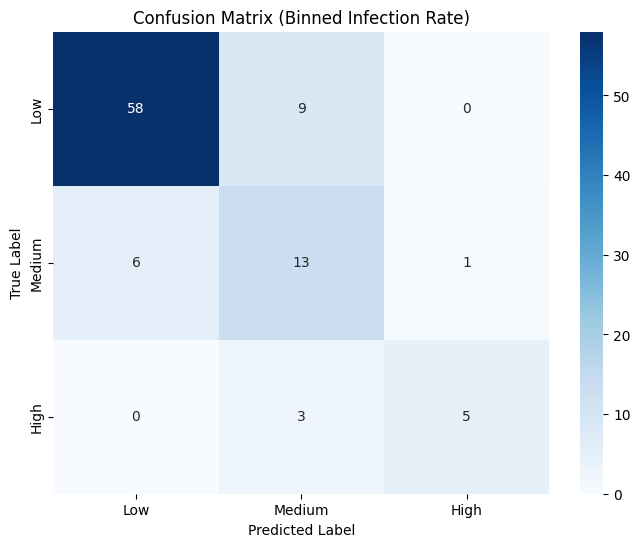

=== 분류 관점에서의 성능 평가 ===
              precision    recall  f1-score   support

         Low       0.91      0.87      0.89        67
      Medium       0.52      0.65      0.58        20
        High       0.83      0.62      0.71         8

    accuracy                           0.80        95
   macro avg       0.75      0.71      0.73        95
weighted avg       0.82      0.80      0.81        95

최적 모델의 Test R2 Score: 0.8000


In [78]:
# 1. 가짜 데이터를 생성해서 Mid, High 개수를 Low만큼 뻥튀기합니다.
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 2. 뻥튀기된 데이터로 학습 (가중치 옵션 없이도 데이터가 많아서 잘 배움)
best_model.set_params(max_depth=5)
best_model.fit(X_train_resampled, y_train_resampled) # resampled 데이터 사용!

# 
pred = best_model.predict(X_test)

# 4. Confusion Matrix 생성
cm = confusion_matrix(y_test, pred)
class_names = ['Low', 'Medium', 'High']

# 5. 시각화 (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Binned Infection Rate)')
plt.show()

# 6. 상세 점수 확인
print("=== 분류 관점에서의 성능 평가 ===")
print(classification_report(y_test, pred, target_names=class_names))
test_score = best_model.score(X_test, y_test)
print(f"최적 모델의 Test R2 Score: {test_score:.4f}")

과적합을 줄이기 위해 max_depth를 5로 제한하는 실험도 해보았으나, 일반화 성능(Accuracy)이 오히려 5%p 하락


원래 모델이 나음..

=== 튜닝 결과 ===

- 가장 좋은 파라미터: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
- 가장 좋은 교차검증 점수: 0.7283
- 최적 모델의 Test R2 Score: 0.8526

### analysis 2. 모델 변수 중요도 분석

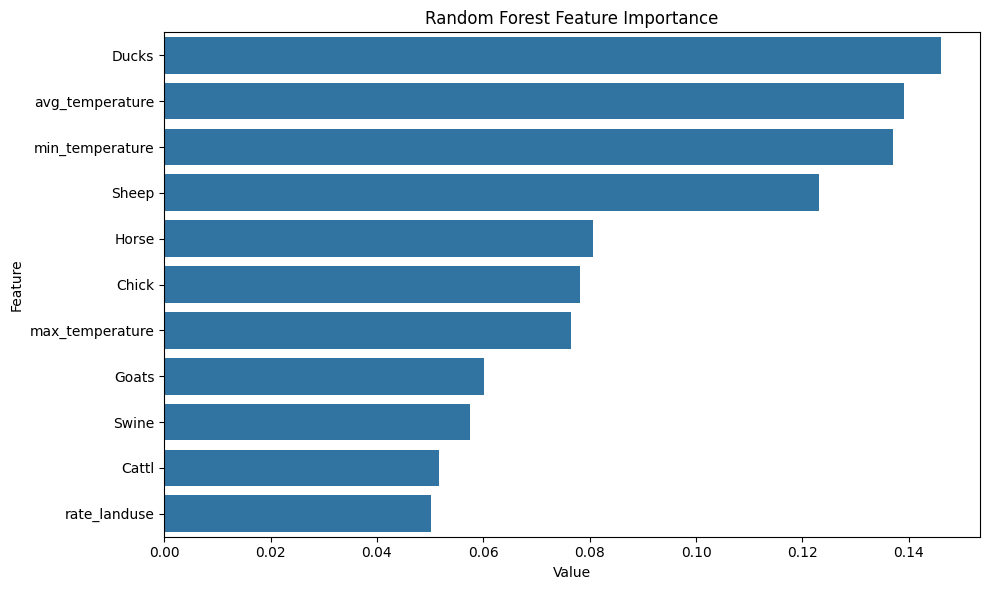

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. 최적 모델에서 변수 중요도 뽑기
importances = rf.feature_importances_
feature_names = X.columns

# 2. 보기 좋게 데이터프레임 만들기
feature_imp = pd.DataFrame(sorted(zip(importances, feature_names)), columns=['Value','Feature'])
feature_imp = feature_imp.sort_values(by="Value", ascending=False)

# 3. 그래프 그리기
plt.figure(figsize=(10, 6))
sns.barplot(x="Value", y="Feature", data=feature_imp)
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

/var/folders/qk/g_3547n500j0qd7wpq7p90_r0000gn/T/ipykernel_73145/1687762747.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')


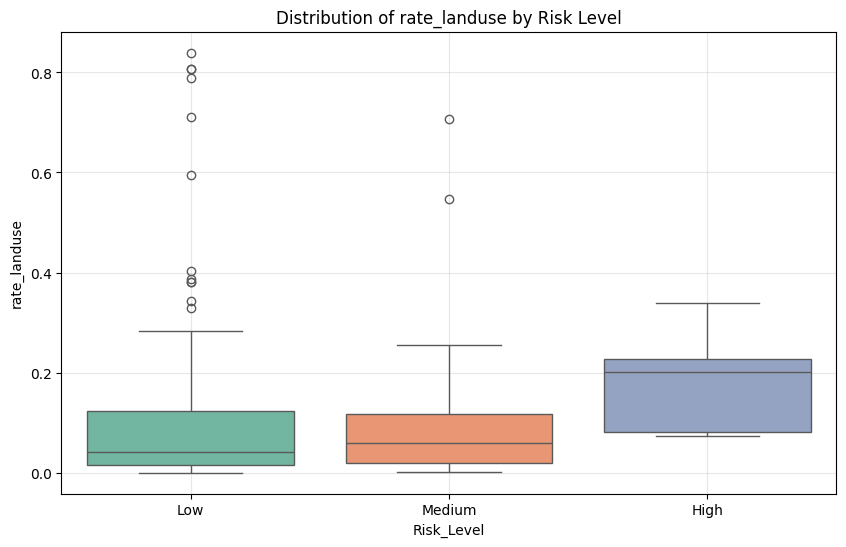

In [ ]:
# 분석용 데이터셋 만들기 (X_test와 y_test 합치기)
analysis_df = X_test.copy()
# y_test는 0,1,2 숫자이므로 보기 좋게 문자로 변환
target_map = {0: 'Low', 1: 'Medium', 2: 'High'}
analysis_df['Risk_Level'] = y_test.map(target_map)

top_feature = feature_imp.iloc[10]['Feature'] 

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')
plt.title(f'Distribution of {top_feature} by Risk Level')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/qk/g_3547n500j0qd7wpq7p90_r0000gn/T/ipykernel_73145/3581325728.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')


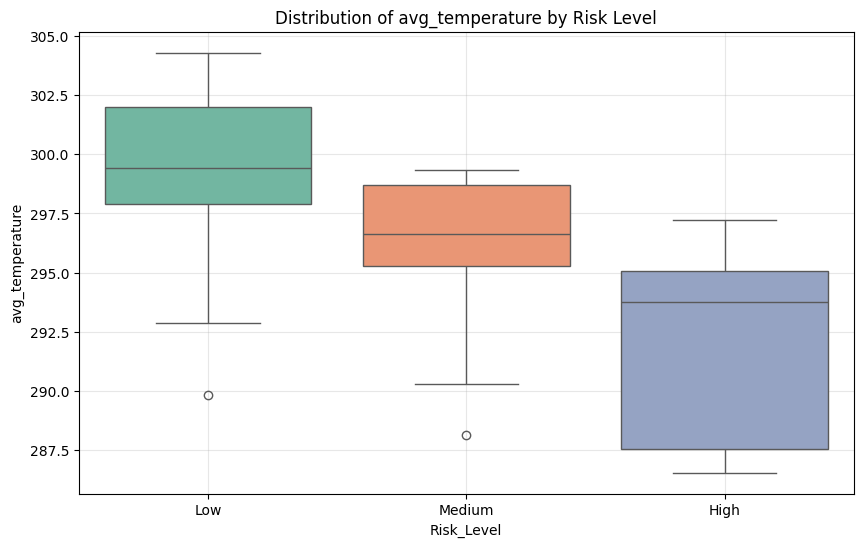

In [110]:
top_feature = feature_imp.iloc[1]['Feature'] 

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')
plt.title(f'Distribution of {top_feature} by Risk Level')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/qk/g_3547n500j0qd7wpq7p90_r0000gn/T/ipykernel_73145/3377964313.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')


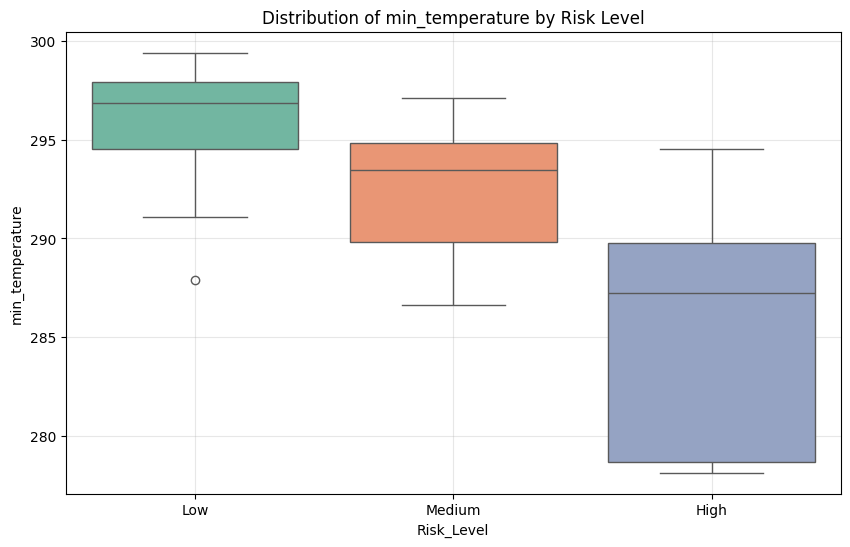

In [112]:
top_feature = feature_imp.iloc[2]['Feature'] 

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')
plt.title(f'Distribution of {top_feature} by Risk Level')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/qk/g_3547n500j0qd7wpq7p90_r0000gn/T/ipykernel_73145/737825691.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')


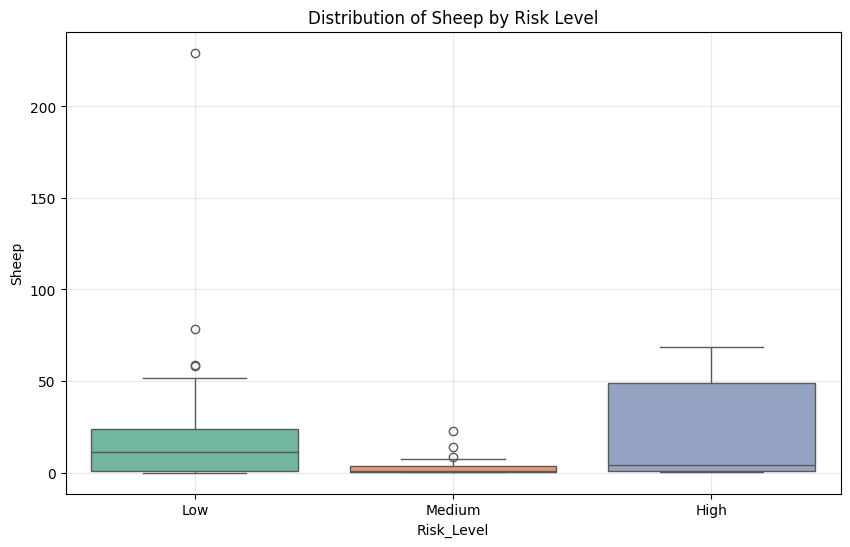

In [113]:
top_feature = feature_imp.iloc[3]['Feature'] 

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')
plt.title(f'Distribution of {top_feature} by Risk Level')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/qk/g_3547n500j0qd7wpq7p90_r0000gn/T/ipykernel_73145/1830733635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')


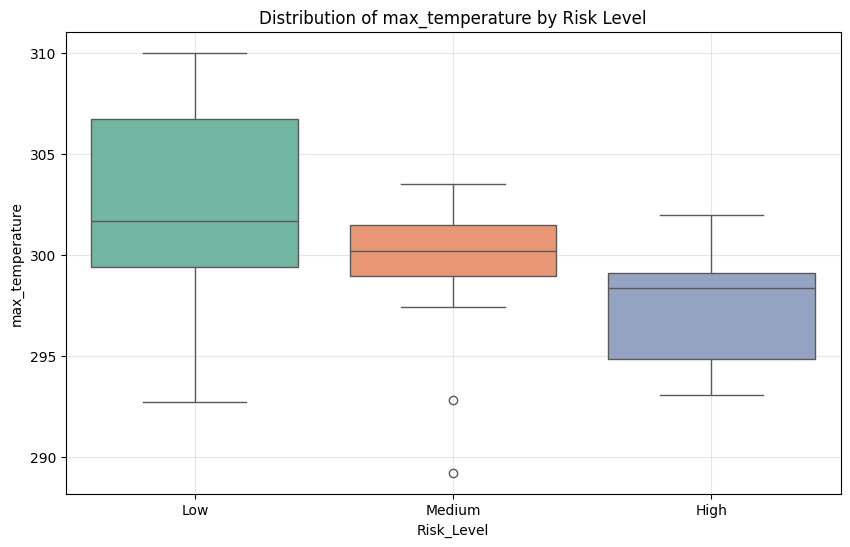

In [117]:
top_feature = feature_imp.iloc[6]['Feature'] 

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')
plt.title(f'Distribution of {top_feature} by Risk Level')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/qk/g_3547n500j0qd7wpq7p90_r0000gn/T/ipykernel_73145/4023975054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')


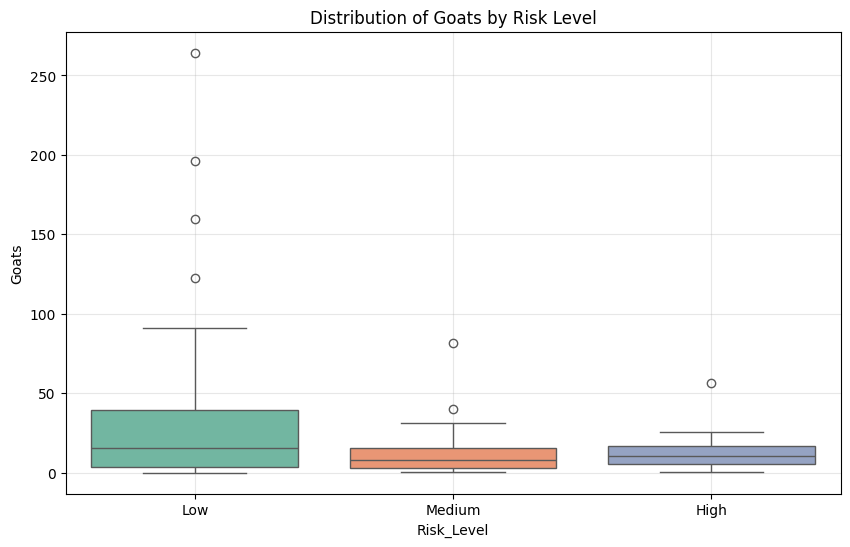

In [118]:
top_feature = feature_imp.iloc[7]['Feature'] 

plt.figure(figsize=(10, 6))
sns.boxplot(data=analysis_df, x='Risk_Level', y=top_feature, order=['Low', 'Medium', 'High'], palette='Set2')
plt.title(f'Distribution of {top_feature} by Risk Level')
plt.grid(True, alpha=0.3)
plt.show()

random forest 모델의 feature importance와 상반된 boxplot

- Feature Importance 점수: 모델이 내부적으로 계산한 "기여도 총합"일 뿐, 절대적인 진리는 아닙니다.
- Boxplot 시각화: 데이터가 실제로 어떻게 나뉘는지 보여주는 **"팩트(Fact)"**입니다.

① Importance 측정 방식의 한계 (Gini Importance)
랜덤 포레스트는 변수 중요도를 계산할 때, **"이 변수를 사용했을 때 불순도(Impurity)가 얼마나 많이 감소했는가?"**를 봅니다.

1등 변수(Sheep):

트리의 **상단(Root)**부터 하단까지 골고루, 자주 쓰이면서 조금씩 조금씩 불순도를 낮췄을 가능성이 큽니다. (잔매가 많음)

그래서 총합 점수(Importance)는 가장 높게 나왔을 수 있습니다.

2등 변수(max_temperature):

트리의 특정 분기점에서 한 방에 강력하게 데이터를 쪼갰을 수 있습니다. (결정타)

Boxplot에서 보이듯, High 그룹과 Low/Medium 그룹을 명확하게 분리하는 능력은 기온이 더 뛰어날 수 있습니다.

② 변수의 성격 차이 (연속형 vs 이산형)
Sheep(양)은 마릿수라서 데이터 값의 종류가 매우 많습니다(High Cardinality). 랜덤 포레스트는 이런 변수를 더 선호하는 경향이 있어 점수가 뻥튀기될 수 있습니다.

반면 max_temperature(기온)는 상대적으로 값의 범위가 좁거나 패턴이 단순해서 점수는 낮게 책정됐지만, **실제 분류 성능(변별력)**은 더 좋을 수 있습니다.

### analysis 3. 틀린 결과 분석

In [ ]:
# 1. 예측 결과와 실제 정답 비교 데이터프레임 생성
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred  # 아까 best_model.predict(X_test)한 결과
})

# 2. 틀린 데이터만 추출 (Wrong Cases)
wrong_cases = results[results['Actual'] != results['Predicted']]
print(f"총 틀린 개수: {len(wrong_cases)}개")

# 3. 원본 데이터와 합쳐서 "어떤 애들을 틀렸나?" 확인
# X_test 인덱스를 기준으로 원본 정보를 가져옵니다.
wrong_details = X_test.loc[wrong_cases.index].copy()
wrong_details['Actual'] = wrong_cases['Actual'].map(target_map)
wrong_details['Predicted'] = wrong_cases['Predicted'].map(target_map)

# 4. 틀린 데이터 샘플 출력 (상위 5개)
print("\n=== 오분류 데이터 샘플 (실제값 vs 예측값) ===")
display(wrong_details.head(10))

총 틀린 개수: 14개

=== 오분류 데이터 샘플 (실제값 vs 예측값) ===


,max_temperature,min_temperature,avg_temperature,Cattl,Chick,Ducks,Goats,Horse,Sheep,Swine,rate_landuse,Actual,Predicted
245,289.23340,286.61865,288.14505,148.833885,434.915252,0.405041,40.150370,0.006014,22.787226,9.350143,0.707553,Medium,Low
289,301.80518,296.94630,299.27750,0.216054,18.446808,2.593782,2.152645,0.000000,0.082492,0.586632,0.019538,Medium,Low
271,300.22560,289.76710,295.63757,9.686017,22.891100,0.000000,2.042929,0.113376,3.567358,0.021327,0.004190,Medium,Low
467,298.90674,294.50293,296.76886,8.113624,17.268629,25.591400,8.504431,0.004095,0.286203,2.294977,0.082605,High,Medium
390,301.27246,293.15480,296.75540,9.817140,58.006928,0.092574,7.052414,0.002648,0.650467,5.326004,0.059686,Medium,High
369,294.87378,292.63452,293.74026,84.881040,837.409722,5.695692,122.642198,0.000000,14.494245,42.911829,0.839386,Low,Medium
284,301.59424,297.12598,299.32730,0.260131,20.736114,3.675456,2.626872,0.000000,0.198916,1.410594,0.019484,Medium,Low
386,298.41968,287.56420,293.72390,14.679611,33.777178,0.196260,11.994991,0.174980,1.411858,0.431373,0.073165,High,Medium
393,297.43480,293.64990,294.91850,0.926897,53.923438,0.000000,0.418505,0.000000,0.070180,1.893746,0.013043,Medium,High
440,297.88550,294.51660,295.53317,0.962482,173.069048,0.000000,2.528648,0.000000,0.247181,16.927667,0.018033,Low,Medium
